In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv('melb_data.csv')
print(df.shape)

(13580, 21)


In [3]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

              Missing Count  Percentage (%)
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001
Car                      62        0.456554


In [4]:
df['Car'] = df['Car'].fillna(0)

# remove duplicated rows
df = df.drop_duplicates()

# Fix the Date data type mismatch so it plots chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

In [212]:
print("Check")
print("Number of missing values left in Car column:", df['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df))

Check
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 13580


Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

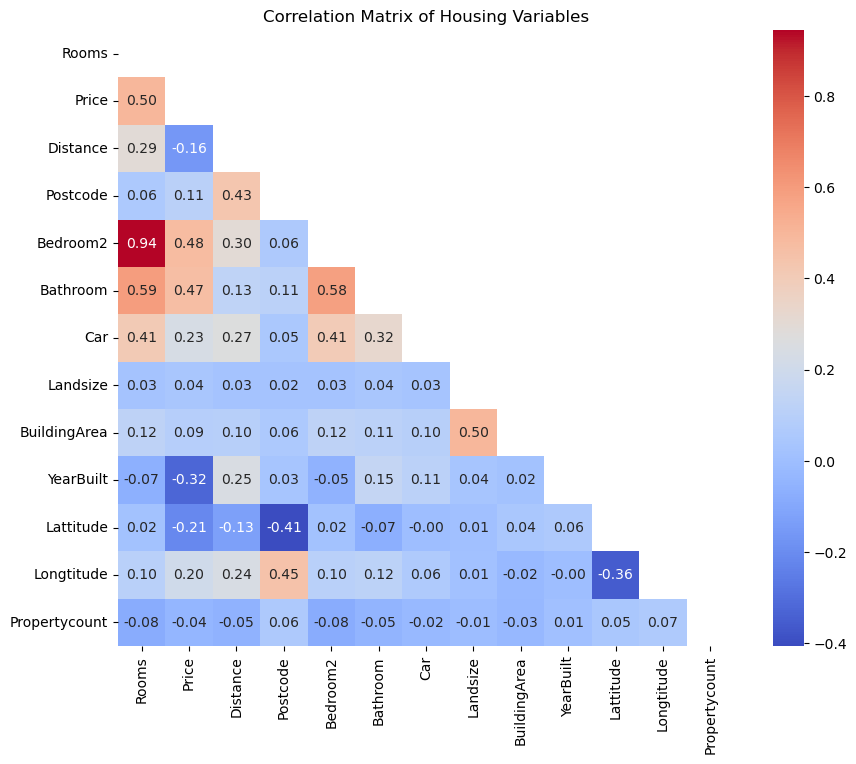

In [5]:
corr = df.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Correlation Matrix of Housing Variables")

In [6]:
# remove columns that we do not need
df = df.drop(
    columns=[
        "BuildingArea",
        "SellerG",
        "Date",
        "Postcode",
        "Address",
        "Propertycount",
        "Method",
        "YearBuilt",
        "Suburb",
        "CouncilArea",
        "Bedroom2",],
    errors="ignore",
)

# creates new features for analysing
df = df.assign(
    Price_per_Landsize = lambda x: x['Price'] / x['Landsize'],
    Distance_Category = pd.cut(
        df['Distance'],
        bins=[0, 10, 20, 30, float('inf')],
        labels=['Near', 'Middle', 'Far', 'Outer']
    )
)

Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

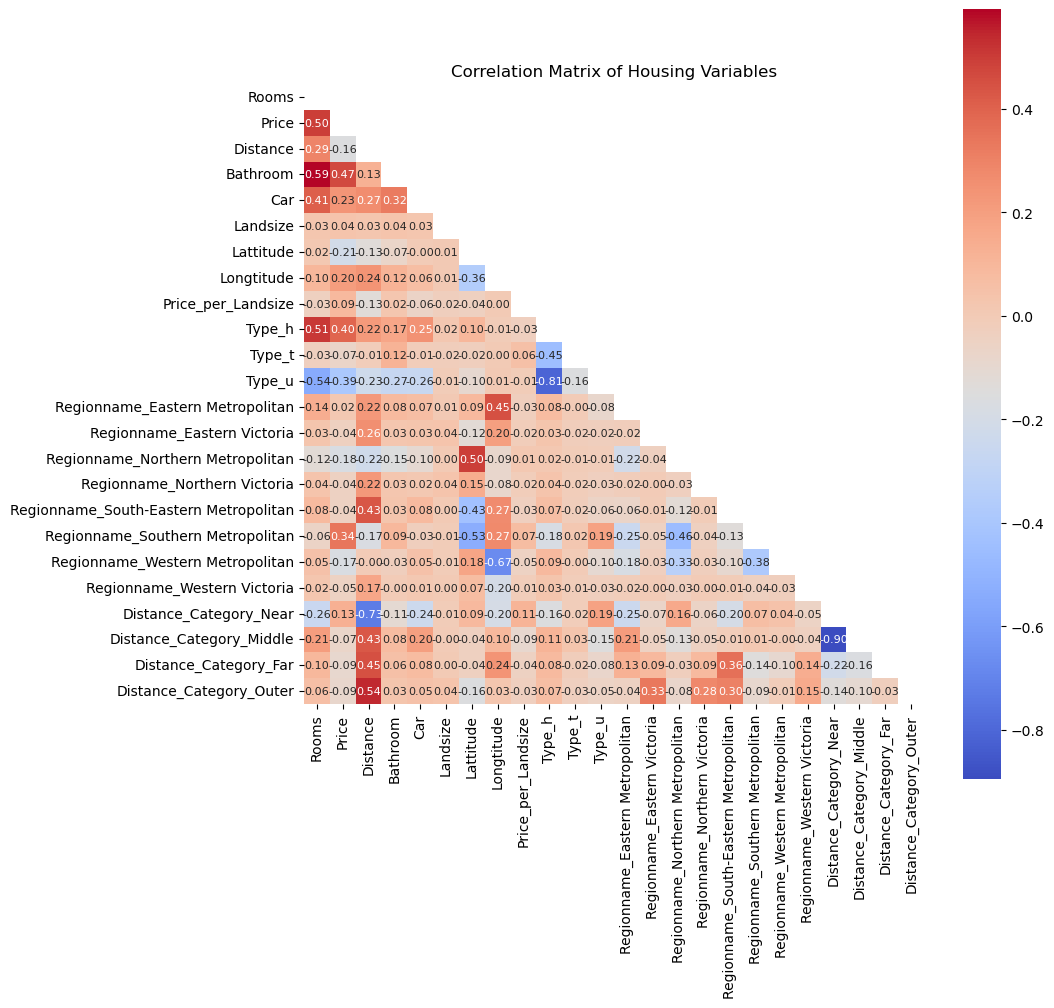

In [7]:
# Convert text columns into numeric binary columns (0 or 1)
df_encoded = pd.get_dummies(df, columns=["Type", "Regionname", "Distance_Category"])

# Now calculate correlation on the newly encoded dataset
corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 10))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True, annot_kws={"size": 8})

plt.title("Correlation Matrix of Housing Variables")

In [8]:
# Clean Landsize
Q1_land = df["Landsize"].quantile(0.25)
Q3_land = df["Landsize"].quantile(0.75)
IQR_land = Q3_land - Q1_land
lower_land = Q1_land - 1.5 * IQR_land
upper_land = Q3_land + 1.5 * IQR_land
df = df[(df["Landsize"] >= lower_land) & (df["Landsize"] <= upper_land)]

# Clean Price
Q1_price = df["Price"].quantile(0.25)
Q3_price = df["Price"].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price
df = df[(df["Price"] >= lower_price) & (df["Price"] <= upper_price)]

# Clean Price per landsize
Q1_Price_per_Landsize = df["Price_per_Landsize"].quantile(0.25)
Q3_Price_per_Landsize = df["Price_per_Landsize"].quantile(0.75)
IQR_Price_per_Landsize = Q3_Price_per_Landsize - Q1_Price_per_Landsize
lower_Price_per_Landsize = Q1_Price_per_Landsize - 1.5 * IQR_Price_per_Landsize
upper_Price_per_Landsize = Q3_Price_per_Landsize + 1.5 * IQR_Price_per_Landsize
df = df[(df["Price_per_Landsize"] >= lower_Price_per_Landsize) & (df["Price_per_Landsize"] <= upper_Price_per_Landsize)]


print("Total rows remaining:", len(df))

Total rows remaining: 10579


In [9]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

                   Missing Count  Percentage (%)
Distance_Category              1        0.009453


In [10]:
# remove the 1 missing value for Distance Category
df = df.dropna(subset=["Distance_Category"])
missing_count = df["Distance_Category"].isna().sum()

print(f"Missing values in Distance_category: {missing_count}")

Missing values in Distance_category: 0


In [11]:
print("Remaining inf values:", np.isinf(df["Price_per_Landsize"]).sum())
print("Total rows remaining:", len(df))

Remaining inf values: 0
Total rows remaining: 10578


In [12]:
# 1. Replace all inf and -inf values with NaN in the Price_per_landsize column
df["Price_per_Landsize"] = df["Price_per_Landsize"].replace(
    [np.inf, -np.inf], np.nan
)

# 2. Drop the rows where Price_per_landsize is now NaN
df = df.dropna(subset=["Price_per_Landsize"])

# Verify that all inf values are gone
print("Remaining inf values:", np.isinf(df["Price_per_Landsize"]).sum())
print("Total rows remaining:", len(df))
print(df.shape)

Remaining inf values: 0
Total rows remaining: 10578
(10578, 12)


In [13]:
df.head()

,Rooms,Type,Price,Distance,Bathroom,Car,Landsize,Lattitude,Longtitude,Regionname,Price_per_Landsize,Distance_Category
0,2,h,1480000.0,2.5,1.0,1.0,202.0,-37.7996,144.9984,Northern Metropolitan,7326.732673,Near
1,2,h,1035000.0,2.5,1.0,0.0,156.0,-37.8079,144.9934,Northern Metropolitan,6634.615385,Near
2,3,h,1465000.0,2.5,2.0,0.0,134.0,-37.8093,144.9944,Northern Metropolitan,10932.835821,Near
3,3,h,850000.0,2.5,2.0,1.0,94.0,-37.7969,144.9969,Northern Metropolitan,9042.553191,Near
5,2,h,941000.0,2.5,1.0,0.0,181.0,-37.8041,144.9953,Northern Metropolitan,5198.895028,Near


In [14]:
df.to_csv('cleaned_melb_dataset.csv', index = False)

Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

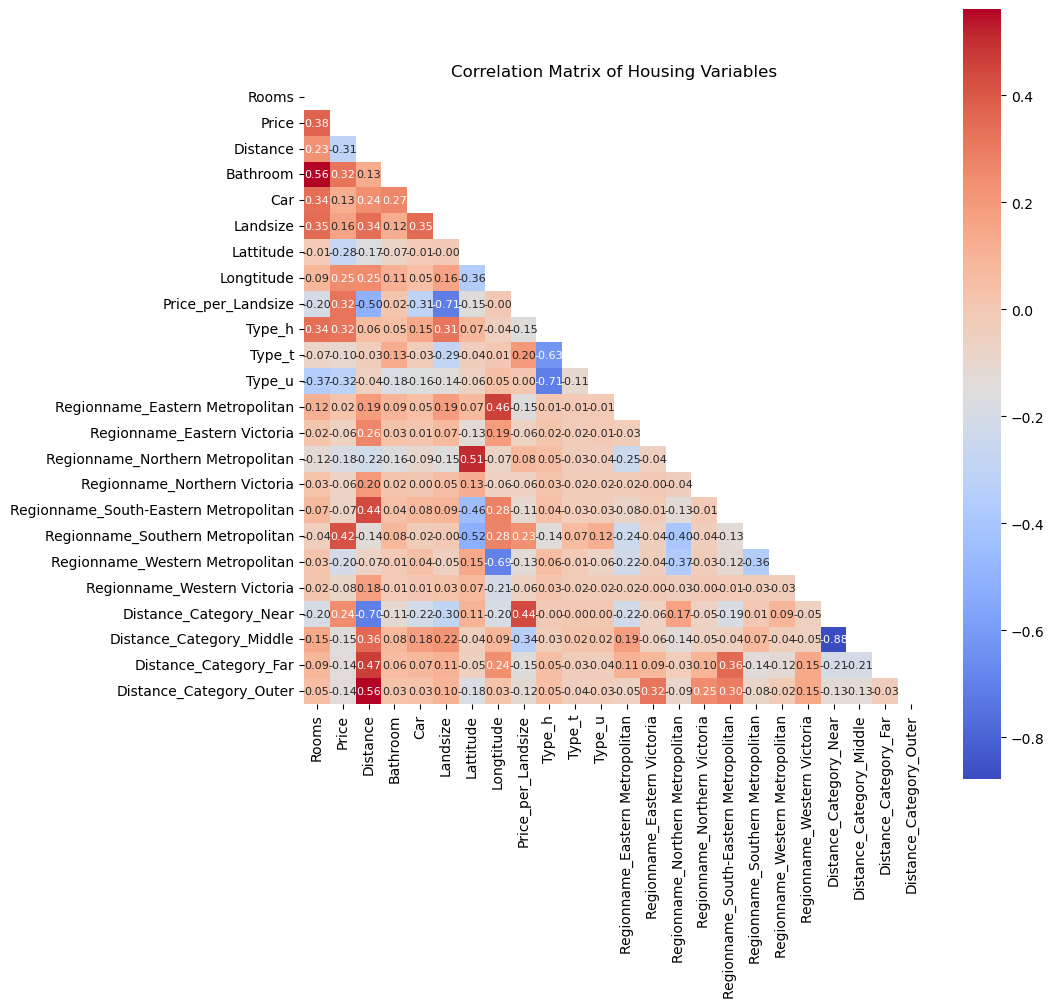

In [15]:
# Convert text columns into numeric binary columns (0 or 1)
df_encoded = pd.get_dummies(df, columns=["Type", "Regionname", "Distance_Category"])

# Now calculate correlation on the newly encoded dataset
corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 10))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True, annot_kws={"size": 8})

plt.title("Correlation Matrix of Housing Variables")

In [16]:
y = df_encoded["Price"]

# X_encoded is all columns EXCEPT Price (the clues)
X_encoded = df_encoded.drop(columns=["Price"])

# This splits your rows into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = 42)

# Find Correlation Lists on Training Data
# We combine X_train and y_train to calculate correlation without data leakage
train_data = X_train.copy()
train_data["Price"] = y_train

# Get absolute correlation values with Price
corr = train_data.corr()
price_corr = corr["Price"].abs()

# Filter lists using your exact syntax
cols_above_04 = price_corr[price_corr > 0.4].index.tolist()
cols_above_03 = price_corr[price_corr > 0.3].index.tolist()

Visualizing Feature Correlations with Price


Text(0.5, 1.0, 'Absolute Feature Correlation with Price')

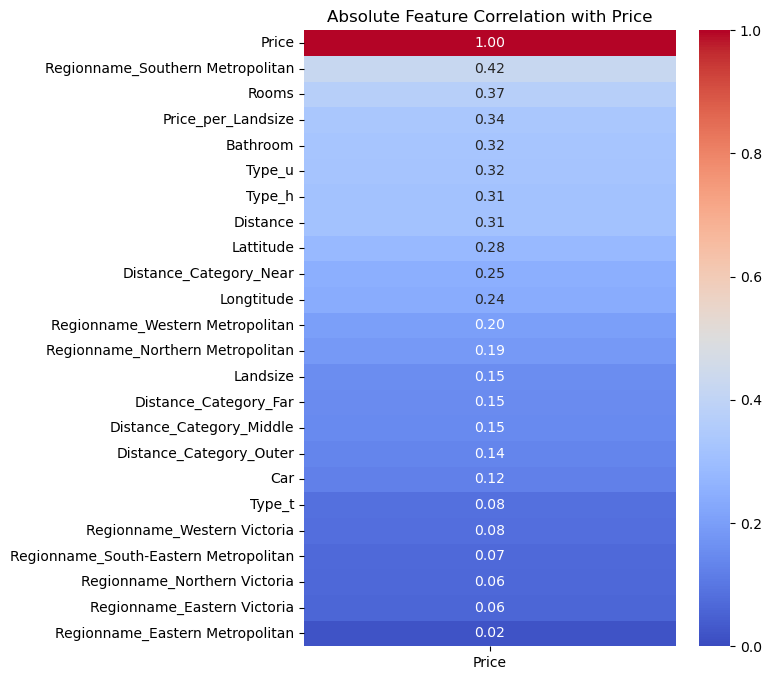

In [17]:
print("Visualizing Feature Correlations with Price")
corr_df = pd.DataFrame(price_corr).sort_values(by="Price", ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", vmin=0, vmax=1, fmt=".2f")
plt.title("Absolute Feature Correlation with Price")

In [18]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model using training data
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
# Predict housing prices using testing data
predictions = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 score:", r2)

Mean Absolute Error: 193127.09965940335
R2 score: 0.672562570279107


In [21]:
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 193127.09965940335
R² Score: 0.672562570279107


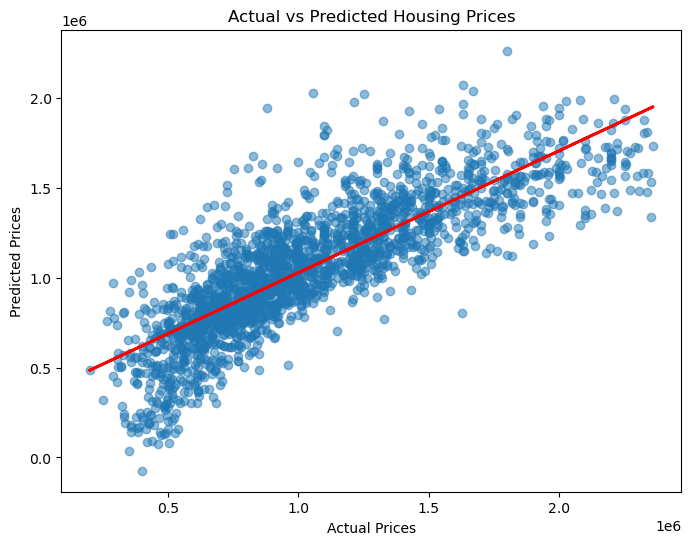

In [22]:
# Plot Actual vs Predicted Prices

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

# Calculate and plot the regression line (y = mx + c)
m, c = np.polyfit(y_test, predictions, 1)
plt.plot(
    y_test, 
    m * y_test + c, 
    color="red", 
    linewidth=2, 
    label="Regression Line"
)

# Add labels and title
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")

plt.show()